In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.mode.copy_on_write = True

# Last bygningsbestand fra SSB (2022-snapshot, årlig oppløsning per byggeår)
df_base = pd.read_csv('data/bygningsbestand_2022.csv')

# Bygningsbestand: antall boliger per byggeår
base_stock = df_base.set_index('byggeaar')['antall_boliger']

# Energiforbruk per husholdning per byggeår-kohort (kWh)
carriers = ['Elektrisitet', 'Ved, pellets og vedbriketter', 'Gass og fjernvarme']
base_energy = df_base.set_index('byggeaar')[carriers]

print(f"Bygningsbestand 2022: {base_stock.sum():,.0f} eneboliger")
print(f"Byggeår-kohorter: {base_stock.index.min()}–{base_stock.index.max()}")
base_energy

Bygningsbestand 2022: 1,290,003 eneboliger
Byggeår-kohorter: 1900–2022


,Elektrisitet,"Ved, pellets og vedbriketter",Gass og fjernvarme
byggeaar,,,
1900,14385.0,2627.0,224.0
1901,14385.0,2627.0,224.0
1902,14385.0,2627.0,224.0
1903,14385.0,2627.0,224.0
1904,14385.0,2627.0,224.0
...,...,...,...
2018,12559.0,882.0,948.0
2019,12559.0,882.0,948.0
2020,12559.0,882.0,948.0


### Scenarioparametere

Alle forutsetninger samlet på ett sted. Endre verdiene her for å kjøre ulike scenarier.

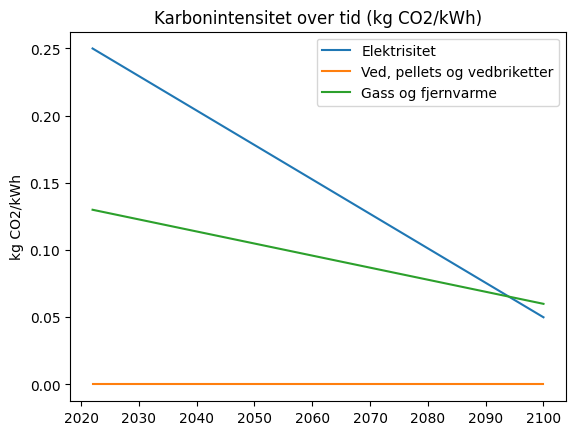

In [45]:
projection_years = range(2022, 2101)

# --- Riving ---
demolition_rate = 0.002

# --- Nybygg ---
new_per_year = 5000  # antall nye eneboliger per år

# Energiprofil for nye boliger (kWh/husholdning) — strengere TEK-krav
new_energy = pd.Series({
    'Elektrisitet':                   10000,
    'Ved, pellets og vedbriketter':    300,
    'Gass og fjernvarme':              300,
})

# --- Karbonintensiteter (kg CO2/kWh) over tid ---
carbon_intensity = pd.DataFrame({
    'Elektrisitet':                   np.linspace(0.250, 0.050, len(projection_years)),
    'Ved, pellets og vedbriketter':   np.full(len(projection_years), 0.0),
    'Gass og fjernvarme':             np.linspace(0.130, 0.060, len(projection_years)),
}, index=projection_years)

carbon_intensity.plot(title='Karbonintensitet over tid (kg CO2/kWh)', ylabel='kg CO2/kWh')
plt.show()

### Projiser bygningsbestand

Kohort-år-matrise: rader = byggeår (1900–2100), kolonner = projeksjonsår (2022–2100).  
Hvert år: eksisterende boliger krymper (riving), ny kohort legges til.

<BarContainer object of 201 artists>

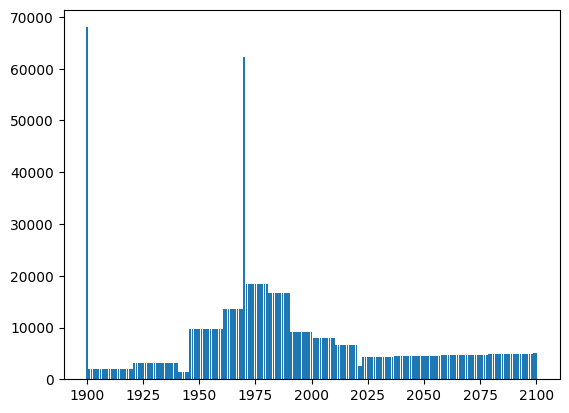

In [46]:
all_byggeaar = range(1900, 2101)

# Bygningsbestand-matrise: (byggeår × projeksjonsår)
stock = pd.DataFrame(0.0, index=all_byggeaar, columns=projection_years)
stock.index.name = 'byggeaar'

# Sett startår fra SSB-data
stock.loc[:, 2022] = base_stock.reindex(all_byggeaar, fill_value=0.0)

# Projiser fremover
for yr in range(2023, 2101):
    stock.loc[:, yr] = stock[yr - 1] * (1 - demolition_rate)
    stock.loc[yr, yr] = new_per_year

plt.bar(all_byggeaar, stock[2100])

### Energiforbruk og utslipp

For eksisterende kohorter: bruker SSB 2022-verdier (kWh/husholdning).  
For nye kohorter (2023+): bruker `new_energy`-profilen.  
Utslipp = energi × karbonintensitet (som endres over tid).

/var/folders/z8/gvgsgtzj6wdg9x1hyg_5gbh80000gn/T/ipykernel_17654/350469818.py:13: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment.
When using the Copy-on-Write mode, such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy.

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_energy[carrier] = stock.multiply(energy_profile[carrier], axis=0).sum(axis=0)


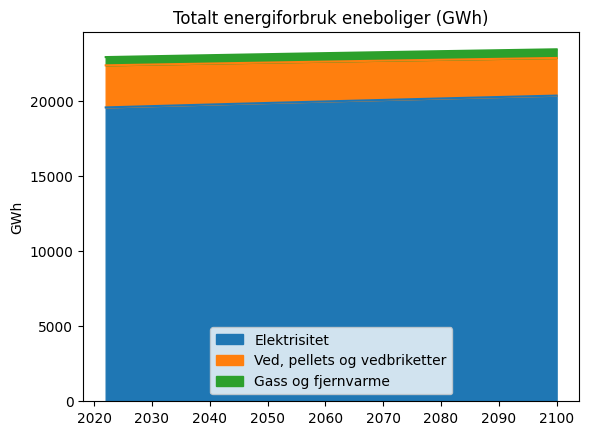

In [47]:
# Energiprofil per byggeår-kohort (kWh/husholdning per energibærer)
# Eksisterende kohorter: SSB-verdier. Nye kohorter (2023+): new_energy.
energy_profile = base_energy.reindex(all_byggeaar)
for yr in range(2023, 2101):
    energy_profile.loc[yr] = new_energy
energy_profile = energy_profile.fillna(0.0)

# Total energi per energibærer per projeksjonsår (kWh)
# For hvert projeksjonsår: sum over kohorter av (antall_boliger × kWh_per_bolig)
total_energy = pd.DataFrame(0.0, index=projection_years, columns=carriers)
for carrier in carriers:
    # energy_profile[carrier] er en vektor over byggeår, stock[yr] likeså
    total_energy[carrier] = stock.multiply(energy_profile[carrier], axis=0).sum(axis=0)

total_energy_gwh = total_energy / 1e6  # kWh → GWh
total_energy_gwh.plot.area(title='Totalt energiforbruk eneboliger (GWh)', ylabel='GWh')
plt.show()

Utslipp 2022: 4,747,425 tonn CO2
Utslipp 2050: 3,334,833 tonn CO2
Utslipp 2100: 872,262 tonn CO2


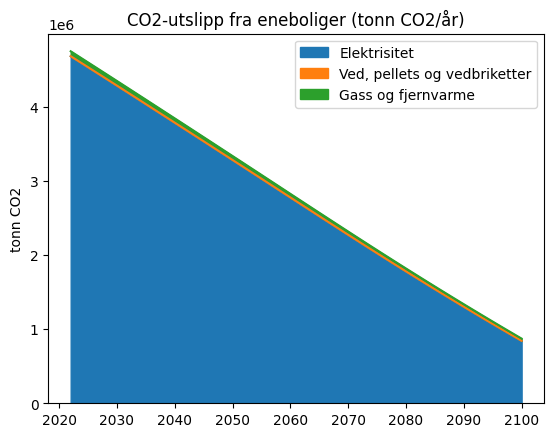

In [12]:
# Utslipp per energibærer per projeksjonsår (tonn CO2)
# total_energy[carrier] × carbon_intensity[carrier] → kg CO2, / 1e3 → tonn
emissions = pd.DataFrame(0.0, index=projection_years, columns=carriers)
for carrier in carriers:
    emissions[carrier] = total_energy[carrier] * carbon_intensity[carrier] / 1e3

emissions['Totalt'] = emissions[carriers].sum(axis=1)

print(f"Utslipp 2022: {emissions.loc[2022, 'Totalt']:,.0f} tonn CO2")
print(f"Utslipp 2050: {emissions.loc[2050, 'Totalt']:,.0f} tonn CO2")
print(f"Utslipp 2100: {emissions.loc[2100, 'Totalt']:,.0f} tonn CO2")

emissions[carriers].plot.area(title='CO2-utslipp fra eneboliger (tonn CO2/år)', ylabel='tonn CO2')
plt.show()

### Sammendrag

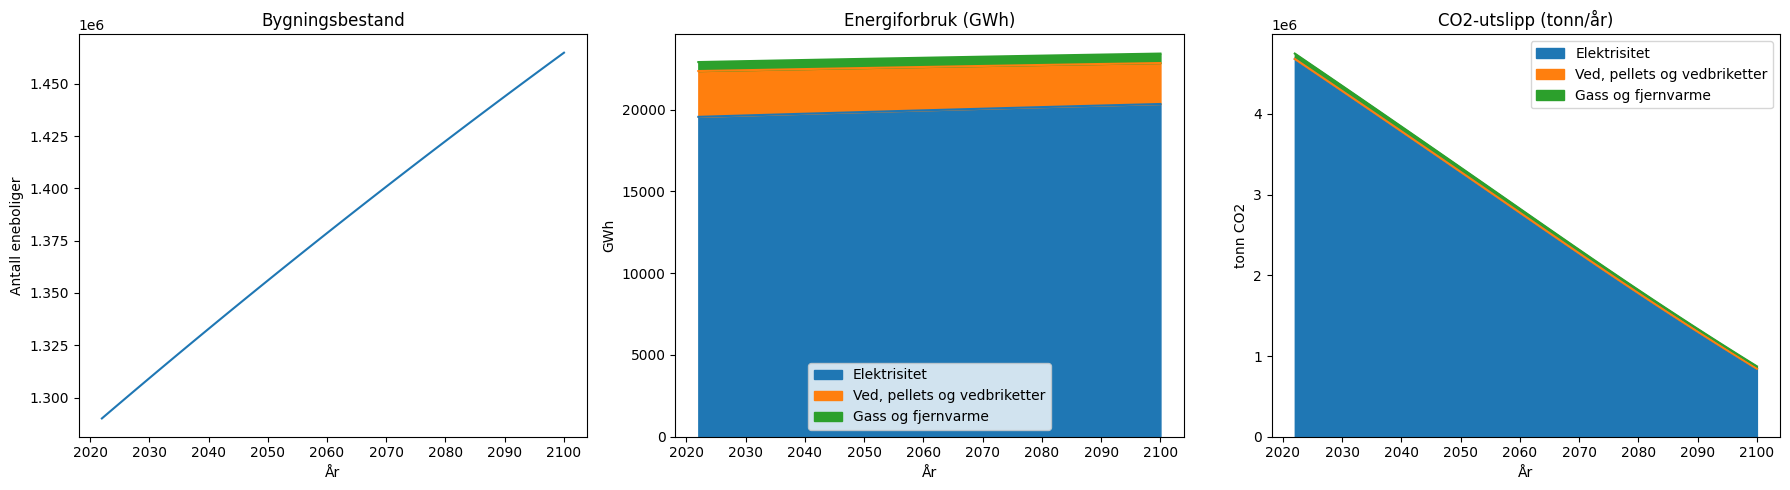

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

total_stock.plot(ax=axes[0], title='Bygningsbestand', ylabel='Antall eneboliger')
total_energy_gwh.plot.area(ax=axes[1], title='Energiforbruk (GWh)', ylabel='GWh')
emissions[carriers].plot.area(ax=axes[2], title='CO2-utslipp (tonn/år)', ylabel='tonn CO2')

for ax in axes:
    ax.set_xlabel('År')

plt.tight_layout()
plt.show()

In [ ]:
*